# 09 — Operational Evaluation: 3×2 Coherence Comparison

**Author:** Florian Klaver

**Prerequisites:** Notebooks 07 and 08 must have run.
Models `s2only_retrained.joblib`, `s2coh_best.joblib`, `coh_only_best.joblib`
must exist in `models/`.

---

## Goal

Apply three models to a held-out scene and produce a 3×2 evaluation table:

|               | No Postprocessing | Morphological+SLIC |
|---------------|-------------------|-----------------------|
| **S2-only**   | F1 = ?            | F1 = ?               |
| **S2+Coh**    | F1 = ?            | F1 = ?               |
| **Coh-only**  | F1 = ?            | F1 = ?               |

The scene is selected automatically: the script finds all match_ids where
both coherence TIFs exist, `coh_before.tif` is non-zero, and the GT mask
has mowed pixels. The user can override `CHOSEN_MATCH_ID` to switch scenes.

Results are saved to `RESULTS_DIR/eval_table.csv` (appended across runs).

---
## 1. Setup

In [135]:
import sys
import os
import importlib
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import joblib
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

import src.evaluation
importlib.reload(src.evaluation)          # pick up any changes to evaluation.py
from src.evaluation import (
    FEATURE_NAMES, prepare_scene_features, run_prediction, evaluate_and_visualize
)
from src.postprocessing import postprocess_prediction
importlib.reload(src.config) # pick up any changes to config.py
from src.config import *

# --- Paths (from src.config) ---
S2_DIR       = S2_SCENES_DIR
MASKS_DIR    = GT_MASKS_DIR
AV_DATA_PATH = AV_LANDUSE_PATH
FB_DATA_PATH = AV_FIREBRIGADE_PATH
OUTPUT_DIR   = RESULTS_DIR
TEMPORAL_CSV = TEMPORAL_MATCHES_CSV

os.makedirs(OUTPUT_DIR, exist_ok=True)

COH_FEATURES = ['coh_vv', 'coh_vh', 'coh_vv_jump', 'coh_vh_jump']

print('Setup complete.')

Setup complete.


---
## 2. Scene Selection

Discover all match_ids with valid coherence data (non-zero `coh_before.tif`)
and a GT mask with at least one mowed pixel. Set `CHOSEN_MATCH_ID` to override
the automatic selection (first candidate by date).

In [136]:
from pathlib import Path

def find_valid_scenes(matches_df, coh_dir, masks_dir, n=5):
    """Return up to n match_ids where coh_before/after exist, before is non-zero,
    and the GT mask has at least one mowed pixel. Sorted by event_date."""
    candidates = []
    for _, row in matches_df.iterrows():
        mid = int(row['match_id'])
        bf  = Path(coh_dir) / f'{mid}_coh_before.tif'
        af  = Path(coh_dir) / f'{mid}_coh_after.tif'
        if not (bf.exists() and af.exists()):
            continue
        with rasterio.open(bf) as src:
            if src.read(1).max() == 0:   # SNAP silent failure
                continue
        gt = Path(masks_dir) / row['mask_file']
        if not gt.exists():
            continue
        with rasterio.open(gt) as src:
            if src.read(1).max() == 0:   # no mowed pixels
                continue
        candidates.append(row)
    df = pd.DataFrame(candidates)
    if df.empty:
        return df
    return df.sort_values('event_date').head(n).reset_index(drop=True)

matches_df = pd.read_csv(TEMPORAL_CSV)
matches_df.insert(0, 'match_id', matches_df.index)  # match_id = 0-based row index, consistent with COH_DIR filenames
matches_df['event_date'] = pd.to_datetime(matches_df['event_date'])

candidates = find_valid_scenes(matches_df, COH_DIR, MASKS_DIR)

print(f'Found {len(candidates)} valid scenes with non-zero coherence and mowed GT pixels:')
display_cols = ['match_id', 'event_date', 'after_file', 'before_near_file', 'mask_file']
if not candidates.empty:
    print(candidates[display_cols].to_string(index=False))

# ── Choose scene ──────────────────────────────────────────────────────────
# Set CHOSEN_MATCH_ID to any match_id from the list above to evaluate a
# different scene. Leave as None to use the first candidate automatically.
CHOSEN_MATCH_ID = 12

if candidates.empty:
    raise RuntimeError('No valid scenes found — run nb06 to compute coherence TIFs')

if CHOSEN_MATCH_ID is None:
    CHOSEN_MATCH_ID = int(candidates.iloc[0]['match_id'])

event = matches_df[matches_df['match_id'] == CHOSEN_MATCH_ID].iloc[0]
coh_match_id  = CHOSEN_MATCH_ID
COH_AVAILABLE = True  # verified by find_valid_scenes

BEFORE_NEAR_S2 = str(S2_DIR / event['before_near_file'])
AFTER_S2       = str(S2_DIR / event['after_file'])
GT_MASK_NAMES  = matches_df[
    matches_df['after_file'] == event['after_file']
]['mask_file'].tolist()

print(f"\nSelected scene: match_id={CHOSEN_MATCH_ID}, date={event['event_date'].date()}")
print(f'  S2 before_near: {event["before_near_file"]}  exists={Path(BEFORE_NEAR_S2).exists()}')
print(f'  S2 after:       {event["after_file"]}  exists={Path(AFTER_S2).exists()}')
print(f'  GT masks:       {GT_MASK_NAMES}')

Found 5 valid scenes with non-zero coherence and mowed GT pixels:
 match_id event_date     after_file before_near_file         mask_file
        0 2019-05-09 2019-05-10.tif   2019-05-05.tif mask_20190509.tif
        1 2019-05-16 2019-05-17.tif   2019-05-12.tif mask_20190516.tif
        2 2019-05-23 2019-05-25.tif   2019-05-20.tif mask_20190523.tif
        3 2019-05-30 2019-06-01.tif   2019-05-27.tif mask_20190530.tif
        4 2019-05-31 2019-06-01.tif   2019-05-27.tif mask_20190531.tif

Selected scene: match_id=12, date=2019-06-23
  S2 before_near: 2019-06-19.tif  exists=True
  S2 after:       2019-06-24.tif  exists=True
  GT masks:       ['mask_20190623.tif']


---
## 3. Load Models

In [137]:
def load_saved_model(filename):
    """Load model saved as {'model': ..., 'features': ..., 'threshold': ...} dict or plain object.
    Returns (model, features, threshold).  threshold defaults to 0.5 for older artifacts."""
    path = os.path.join(MODELS_DIR, filename)
    if not os.path.exists(path):
        print(f'  NOT FOUND: {path}')
        return None, [], 0.5
    obj = joblib.load(path)
    if isinstance(obj, dict):
        return obj['model'], obj.get('features', FEATURE_NAMES), float(obj.get('threshold', 0.5))
    return obj, FEATURE_NAMES, 0.5


model_s2,    feat_s2,    thresh_s2    = load_saved_model('s2only_retrained.joblib')
model_s2coh, feat_s2coh, thresh_s2coh = load_saved_model('s2coh_best.joblib')
model_coh,   feat_coh,   thresh_coh   = load_saved_model('coh_only_best.joblib')

print(f'S2-only:  {len(feat_s2)} features   model={type(model_s2).__name__ if model_s2 else "MISSING"}   threshold={thresh_s2:.4f}')
print(f'S2+Coh:   {len(feat_s2coh)} features   model={type(model_s2coh).__name__ if model_s2coh else "MISSING"}   threshold={thresh_s2coh:.4f}')
print(f'Coh-only: {len(feat_coh)} features    model={type(model_coh).__name__ if model_coh else "MISSING"}   threshold={thresh_coh:.4f}')

S2-only:  5 features   model=Pipeline   threshold=0.2855
S2+Coh:   9 features   model=Pipeline   threshold=0.6259
Coh-only: 4 features    model=Pipeline   threshold=0.3590


---
## 4. Prepare Scene Features

### 4a. S2 features (shared by all optical models)

In [138]:
print('=== Computing S2 scene features ===')
feature_df_s2, valid_mask, meta, H, W = prepare_scene_features(
    BEFORE_NEAR_S2, AFTER_S2, AV_DATA_PATH, FB_DATA_PATH, FEATURE_NAMES
)
print(f'Scene shape:            {H} x {W} pixels')
print(f'Valid grassland pixels: {valid_mask.sum():,} / {H*W:,}  ({valid_mask.sum()/(H*W)*100:.1f}%)')

=== Computing S2 scene features ===
Before: 2019-06-19.tif
After:  2019-06-24.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  [DIAG] scene CRS:             EPSG:2056
  [DIAG] scene bounds:          (2682012.930275509, 1254788.2381722096, 2685824.584985104, 1260380.6659482294)
  [DIAG] GPKG CRS (before reproject): EPSG:2056
  [DIAG] grassland rows:        577
  [DIAG] grassland_mask True:   90,649 / 212,979
  [DIAG] airport_poly rows:     1
  [DIAG] airport_mask True:     81,337 / 212,979
  [DIAG] ~cloud_mask True:      202,237 / 212,979
  [DIAG] ~nan_mask True:        204,241 / 212,979
Scene shape:            559 x 381 pixels
Valid grassland pixels: 32,772 / 212,979  (15.4%)


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


In [139]:
# --- Coherence band helpers ---

def _find_coh_bands(src):
    """
    Return (vv_idx, vh_idx) as 1-based band indices for a SNAP coherence TIF.
    SNAP Interferogram+Coherence always writes 4 bands in order:
      [VV_intensity, VV_coherence, VH_intensity, VH_coherence]
    Bands 2 and 4 are therefore always the coherence bands.
    Hardcoded to avoid the value-range heuristic mis-identifying band 1
    (interferogram) as coherence when intensity values happen to fall in [0,1].
    """
    if src.count >= 4:
        return 2, 4
    if src.count == 2:
        return 1, 2
    return 1, None


def read_coh_band_upsampled(tif_path, band_idx, ref_path):
    """
    Read one band from a 20 m coherence TIF and bilinear-upsample to the 10 m S2 grid.
    Returns a 2-D float32 array with the same shape as the S2 reference.
    """
    with rasterio.open(ref_path) as ref:
        dst_shape     = (ref.height, ref.width)
        dst_transform = ref.transform
        dst_crs       = ref.crs

    with rasterio.open(tif_path) as src:
        src_arr = src.read(band_idx).astype(np.float32)
        src_arr[src_arr <= 0] = np.nan   # SNAP nodata = 0

        dst_arr = np.full(dst_shape, np.nan, dtype=np.float32)
        reproject(
            source=src_arr,
            destination=dst_arr,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
            src_nodata=np.nan,
            dst_nodata=np.nan,
        )
    return dst_arr


def _is_empty_tif(tif_path, band_idx):
    """Return True if the given band is entirely zero (SNAP produced empty output)."""
    with rasterio.open(tif_path) as src:
        arr = src.read(band_idx).astype(np.float32)
        return np.all(arr == 0)


# --- Load and upsample coherence for the scene ---
if COH_AVAILABLE:
    before_path = os.path.join(COH_DIR, f'{coh_match_id}_coh_before.tif')
    after_path  = os.path.join(COH_DIR, f'{coh_match_id}_coh_after.tif')

    with rasterio.open(before_path) as bs:
        vv_b_idx, vh_b_idx = _find_coh_bands(bs)
        print(f'coh_before: {bs.count} bands  VV=band{vv_b_idx}  VH=band{vh_b_idx}  res={bs.res}')
    with rasterio.open(after_path) as as_:
        vv_a_idx, vh_a_idx = _find_coh_bands(as_)
        print(f'coh_after:  {as_.count} bands  VV=band{vv_a_idx}  VH=band{vh_a_idx}  res={as_.res}')

    # Check if before TIF was written correctly by SNAP (non-empty)
    before_empty = _is_empty_tif(before_path, vv_b_idx)
    if before_empty:
        print('\nWARNING: coh_before.tif is all zeros — SNAP produced empty output for this pair.')
        print('         The source SLC files are no longer on disk, so re-processing is not possible.')
        print('         Jump features (coh_vv_jump, coh_vh_jump) will be set to 0 for this scene.')
        print('         S2+Coh and Coh-only results will reflect only absolute coherence (coh_vv, coh_vh),')
        print('         not the mowing-induced coherence change. Expect degraded coherence model performance.')

    coh_a_vv = read_coh_band_upsampled(after_path,  vv_a_idx, AFTER_S2)
    coh_a_vh = read_coh_band_upsampled(after_path,  vh_a_idx, AFTER_S2) if vh_a_idx else np.full_like(coh_a_vv, np.nan)

    # Per-pixel coherence features (flat, same length as H*W)
    # coh_vv / coh_vh: use coh_after (predicting the after period — did mowing happen?)
    coh_vv = coh_a_vv.flatten()
    coh_vh = coh_a_vh.flatten()

    if before_empty:
        # Jump features unavailable; use 0 so models can run without NaN crashes
        coh_vv_jump = np.zeros_like(coh_vv)
        coh_vh_jump = np.zeros_like(coh_vh)
    else:
        coh_b_vv = read_coh_band_upsampled(before_path, vv_b_idx, AFTER_S2)
        coh_b_vh = read_coh_band_upsampled(before_path, vh_b_idx, AFTER_S2) if vh_b_idx else np.full_like(coh_b_vv, np.nan)
        coh_vv_jump = (coh_a_vv - coh_b_vv).flatten()
        coh_vh_jump = (coh_a_vh - coh_b_vh).flatten()

    # Build coherence feature DataFrames
    feature_df_s2coh = feature_df_s2.copy()
    feature_df_s2coh['coh_vv']      = coh_vv
    feature_df_s2coh['coh_vh']      = coh_vh
    feature_df_s2coh['coh_vv_jump'] = coh_vv_jump
    feature_df_s2coh['coh_vh_jump'] = coh_vh_jump

    feature_df_coh = pd.DataFrame({
        'coh_vv':      coh_vv,
        'coh_vh':      coh_vh,
        'coh_vv_jump': coh_vv_jump,
        'coh_vh_jump': coh_vh_jump,
    })

    # Valid mask: S2 valid pixels + coherence non-NaN
    valid_mask_coh = valid_mask & np.isfinite(coh_vv)

    print(f'\nCoherence features (after upsampling to 10 m):')
    print(f'  coh_vv:       min={np.nanmin(coh_a_vv):.3f}  mean={np.nanmean(coh_a_vv):.3f}  max={np.nanmax(coh_a_vv):.3f}')
    print(f'  coh_vh:       min={np.nanmin(coh_a_vh):.3f}  mean={np.nanmean(coh_a_vh):.3f}  max={np.nanmax(coh_a_vh):.3f}')
    if before_empty:
        print(f'  coh_vv_jump:  [set to 0 — before TIF empty]')
        print(f'  coh_vh_jump:  [set to 0 — before TIF empty]')
    else:
        print(f'  coh_vv_jump:  min={np.nanmin(coh_vv_jump):.3f}  mean={np.nanmean(coh_vv_jump):.3f}  max={np.nanmax(coh_vv_jump):.3f}')
        print(f'  coh_vh_jump:  min={np.nanmin(coh_vh_jump):.3f}  mean={np.nanmean(coh_vh_jump):.3f}  max={np.nanmax(coh_vh_jump):.3f}')
    print(f'  Valid pixels (S2 & coh non-NaN): {valid_mask_coh.sum():,}')
else:
    feature_df_s2coh = None
    feature_df_coh   = None
    valid_mask_coh   = None
    print('WARNING: Coherence not available — S2+Coh and Coh-only cells will be skipped.')

coh_before: 4 bands  VV=band2  VH=band4  res=(20.0, 20.0)
coh_after:  4 bands  VV=band2  VH=band4  res=(20.0, 20.0)

Coherence features (after upsampling to 10 m):
  coh_vv:       min=0.040  mean=0.322  max=0.997
  coh_vh:       min=0.048  mean=0.364  max=0.996
  coh_vv_jump:  min=-0.772  mean=-0.071  max=0.708
  coh_vh_jump:  min=-0.773  mean=0.021  max=0.849
  Valid pixels (S2 & coh non-NaN): 32,772


---
## 5. Define Postprocessing Function

Morphological + SLIC using validated parameters from `src/config.py`
(`PP_DISK_RADIUS=2`, `PP_MIN_AREA_PX=4`, `PP_N_SEGMENTS=300`, `PP_COMPACTNESS=0.05`).

In [140]:
with rasterio.open(AFTER_S2) as src:
    r = np.clip(src.read(3).astype(float) / 2500, 0, 1)
    g = np.clip(src.read(2).astype(float) / 2500, 0, 1)
    b = np.clip(src.read(1).astype(float) / 2500, 0, 1)
scene_rgb = np.dstack([r, g, b]).astype(np.float32)

def apply_postprocessing(pred_map):
    return postprocess_prediction(
        pred_map,
        method='morphological',
        scene_image=scene_rgb,
        disk_radius=PP_DISK_RADIUS,       # 2 (from config)
        min_area_pixels=PP_MIN_AREA_PX,   # 4 (from config)
        n_segments=PP_N_SEGMENTS,          # 300 (from config)
        slic_compactness=PP_COMPACTNESS,   # 0.05 (from config)
    )

print(f'Postprocessing: morphological  '
      f'(disk_radius={PP_DISK_RADIUS}, min_area={PP_MIN_AREA_PX}, '
      f'n_segments={PP_N_SEGMENTS}, compactness={PP_COMPACTNESS})')

Postprocessing: morphological  (disk_radius=2, min_area=4, n_segments=300, compactness=0.05)


---
## 6. Run All 6 Cells (3 models x 2 PP settings)

In [141]:
table_results = {}

def run_cell(label, model, feature_df, valid_mask_px, features,
             threshold=0.5, postprocess=False, pp_fn=None):
    """Run one cell: predict with calibrated threshold, optionally postprocess, evaluate."""
    if model is None or feature_df is None or valid_mask_px is None:
        print(f'SKIPPED: {label} — model or features not available')
        return None

    sep = '=' * 60
    print(f'\n{sep}\n{label}  (threshold={threshold:.4f})\n{sep}')
    pred_tag  = label.replace(' ', '_').replace('+', 'plus').replace('|', '').lower().strip('_')
    pred_path = os.path.join(OUTPUT_DIR, f'pred_{pred_tag}.tif')

    avail_feats = [f for f in features if f in feature_df.columns]
    run_prediction(model, feature_df[avail_feats], valid_mask_px, H, W, pred_path, meta,
                   threshold=threshold)

    if postprocess and pp_fn is not None:
        with rasterio.open(pred_path) as src:
            pred_map = src.read(1)
            pp_meta  = src.meta.copy()
        pred_map_pp = pp_fn(pred_map)
        pp_path = pred_path.replace('.tif', '_pp.tif')
        with rasterio.open(pp_path, 'w', **pp_meta) as dst:
            dst.write(pred_map_pp, 1)
        eval_path = pp_path
    else:
        eval_path = pred_path

    metrics = evaluate_and_visualize(eval_path, GT_MASK_NAMES, MASKS_DIR, AFTER_S2, OUTPUT_DIR)
    table_results[label] = metrics
    return metrics


S2-only | No PP  (threshold=0.2855)
Predicting on 32,772 valid pixels (threshold=0.286)...
Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\pred_s2-only__no_pp.tif
REPORT: pred_s2-only__no_pp
              precision    recall  f1-score   support

   No Mowing       0.97      0.63      0.76     29748
      Mowing       0.18      0.83      0.30      3024

    accuracy                           0.64     32772
   macro avg       0.58      0.73      0.53     32772
weighted avg       0.90      0.64      0.72     32772

Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\eval_map_pred_s2-only__no_pp.png


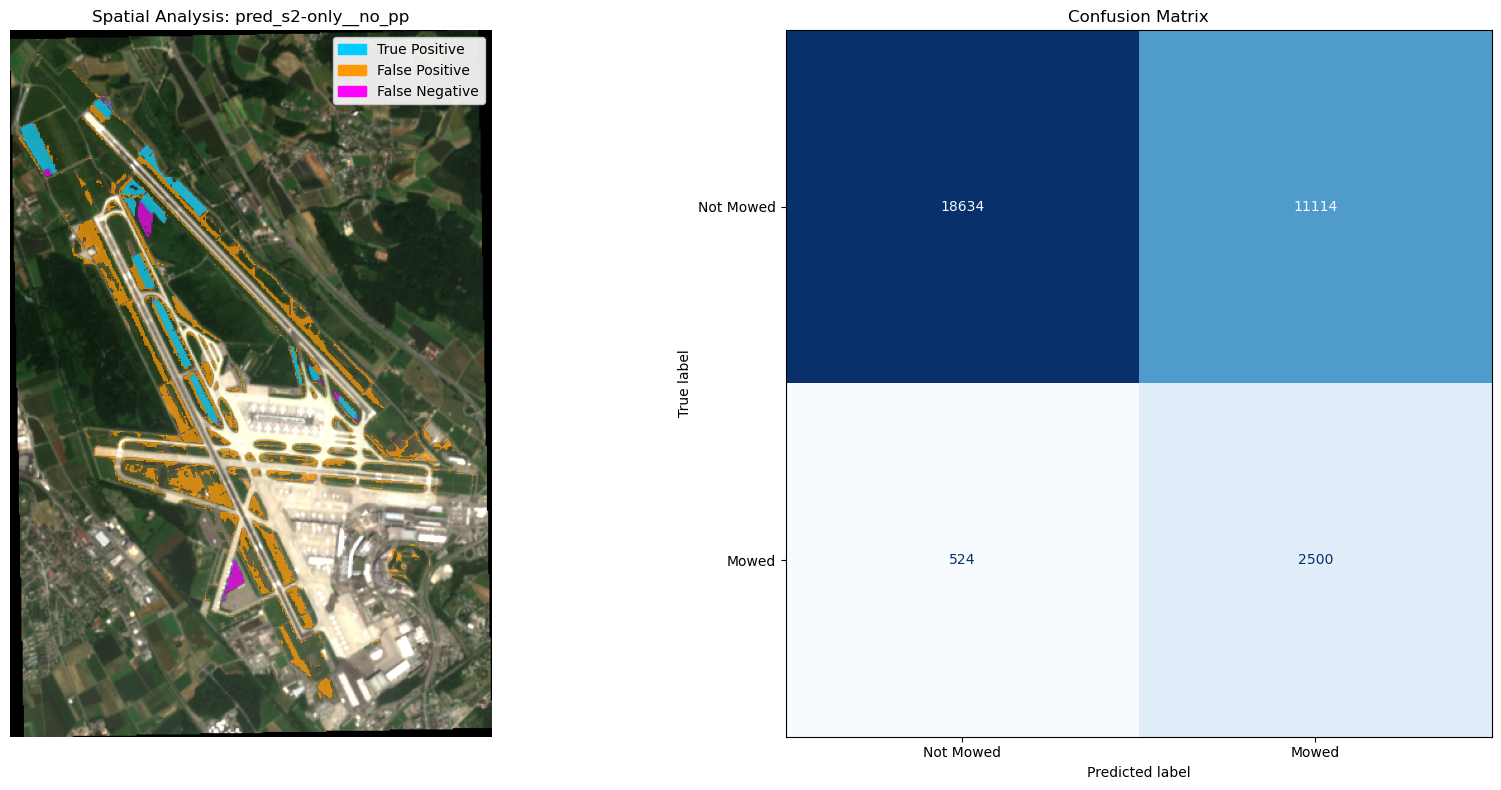


S2-only | Morph+SLIC  (threshold=0.2855)
Predicting on 32,772 valid pixels (threshold=0.286)...
Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\pred_s2-only__morphplusslic.tif
REPORT: pred_s2-only__morphplusslic_pp
              precision    recall  f1-score   support

   No Mowing       0.97      0.83      0.90     29748
      Mowing       0.32      0.78      0.46      3024

    accuracy                           0.83     32772
   macro avg       0.65      0.81      0.68     32772
weighted avg       0.91      0.83      0.86     32772

Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\eval_map_pred_s2-only__morphplusslic_pp.png


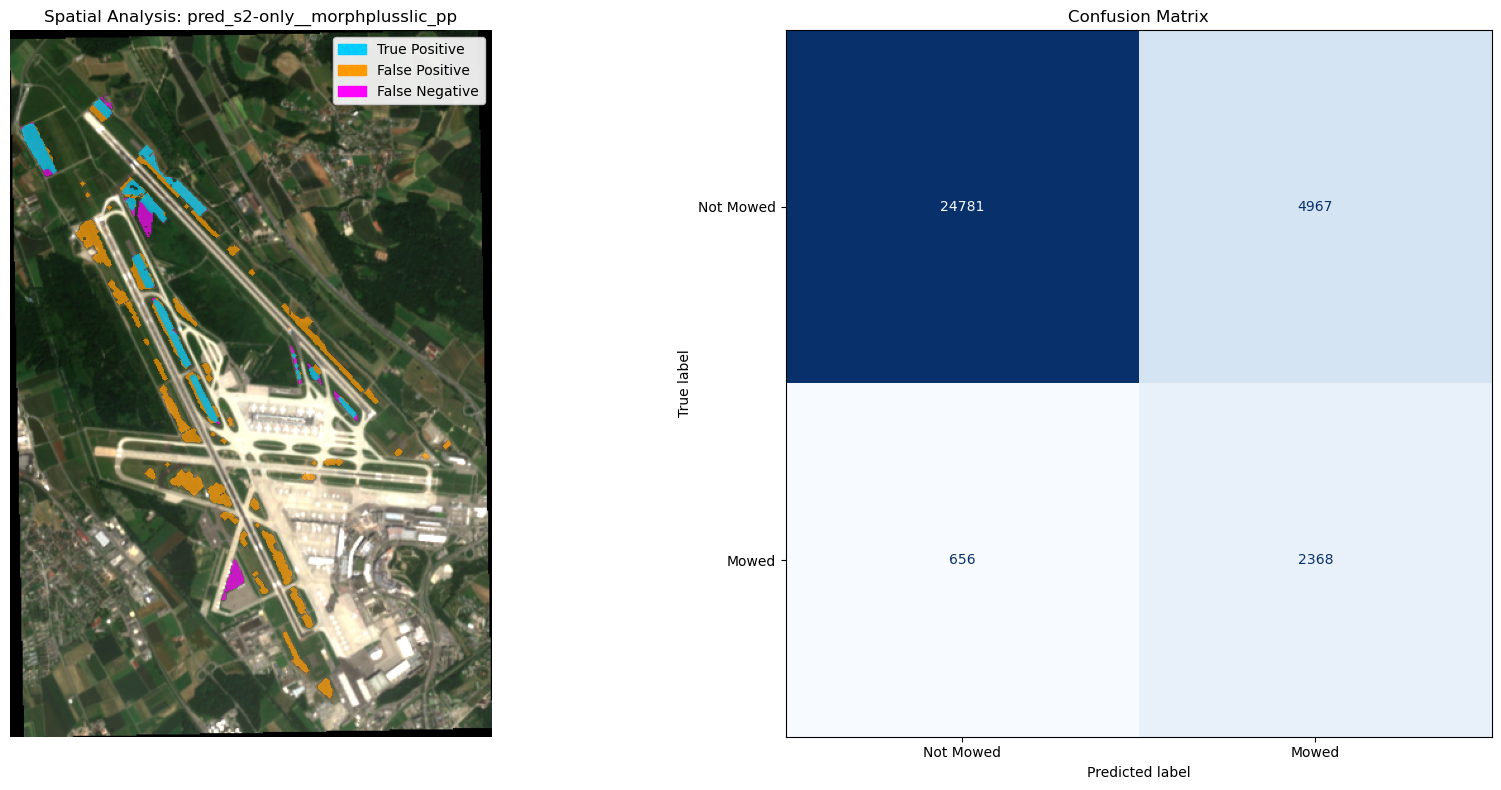

{'accuracy': 0.828420602953741,
 'precision_mowing': 0.3228357191547376,
 'recall_mowing': 0.783068783068783,
 'f1_mowing': 0.4571869871609229,
 'f1_macro': 0.6776466783226921}

In [142]:
# A: S2-only, no postprocessing
run_cell('S2-only | No PP',
         model_s2, feature_df_s2, valid_mask, feat_s2,
         threshold=thresh_s2, postprocess=False)

# B: S2-only, Morphological+SLIC
run_cell('S2-only | Morph+SLIC',
         model_s2, feature_df_s2, valid_mask, feat_s2,
         threshold=thresh_s2, postprocess=True, pp_fn=apply_postprocessing)


S2+Coh | No PP  (threshold=0.6259)
Predicting on 32,772 valid pixels (threshold=0.626)...
Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\pred_s2pluscoh__no_pp.tif
REPORT: pred_s2pluscoh__no_pp
              precision    recall  f1-score   support

   No Mowing       0.98      0.41      0.58     29748
      Mowing       0.14      0.91      0.24      3024

    accuracy                           0.45     32772
   macro avg       0.56      0.66      0.41     32772
weighted avg       0.90      0.45      0.54     32772

Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\eval_map_pred_s2pluscoh__no_pp.png


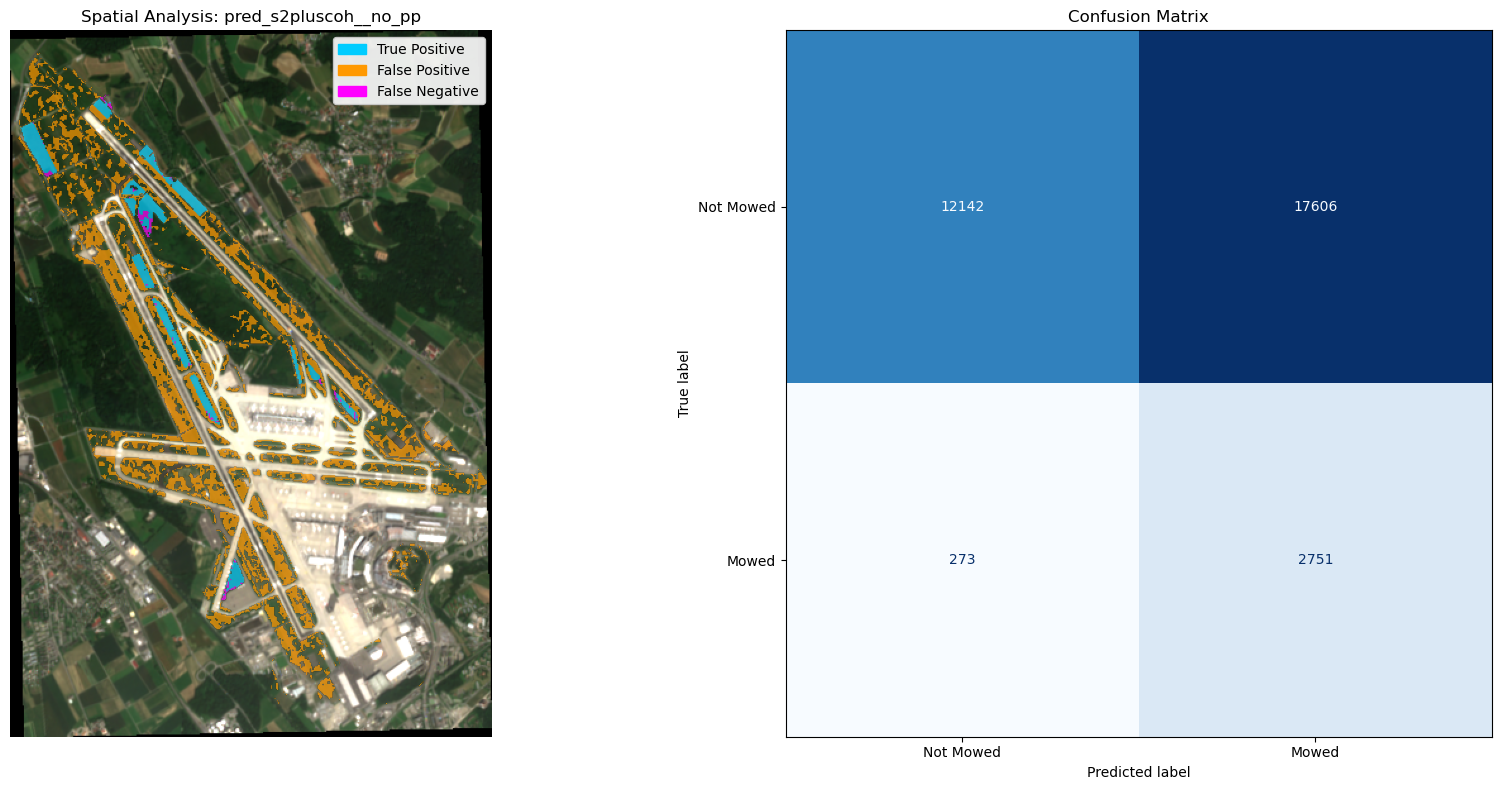


S2+Coh | Morph+SLIC  (threshold=0.6259)
Predicting on 32,772 valid pixels (threshold=0.626)...
Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\pred_s2pluscoh__morphplusslic.tif
REPORT: pred_s2pluscoh__morphplusslic_pp
              precision    recall  f1-score   support

   No Mowing       0.98      0.72      0.83     29748
      Mowing       0.23      0.86      0.37      3024

    accuracy                           0.73     32772
   macro avg       0.61      0.79      0.60     32772
weighted avg       0.91      0.73      0.78     32772

Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\eval_map_pred_s2pluscoh__morphplusslic_pp.png


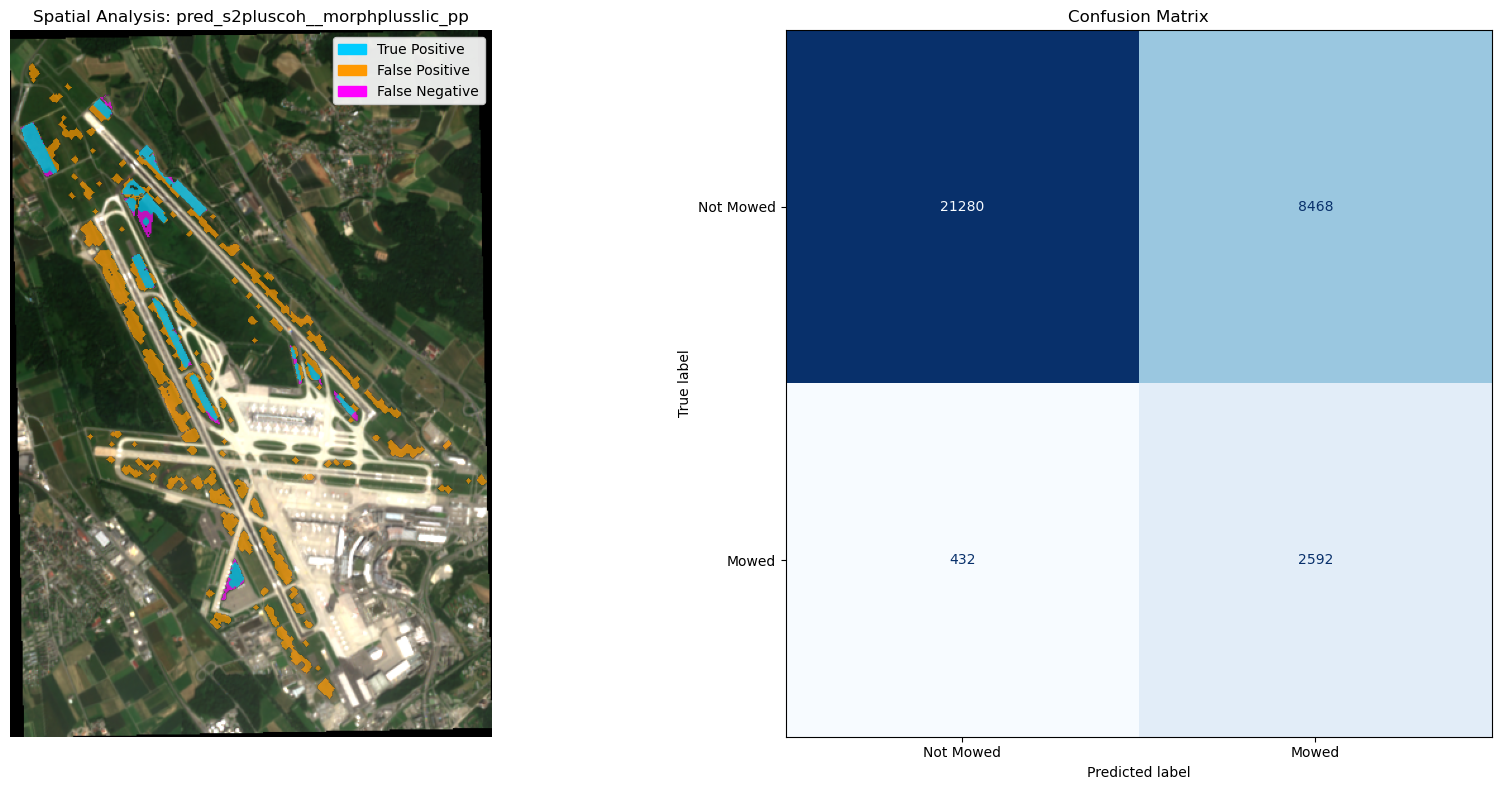

{'accuracy': 0.7284267057243988,
 'precision_mowing': 0.23435804701627486,
 'recall_mowing': 0.8571428571428571,
 'f1_mowing': 0.3680772507810281,
 'f1_macro': 0.5975636934045055}

In [143]:
# C: S2+Coh, no postprocessing
run_cell('S2+Coh | No PP',
         model_s2coh, feature_df_s2coh, valid_mask_coh, feat_s2coh,
         threshold=thresh_s2coh, postprocess=False)

# D: S2+Coh, Morphological+SLIC
run_cell('S2+Coh | Morph+SLIC',
         model_s2coh, feature_df_s2coh, valid_mask_coh, feat_s2coh,
         threshold=thresh_s2coh, postprocess=True, pp_fn=apply_postprocessing)


Coh-only | No PP  (threshold=0.3590)
Predicting on 32,772 valid pixels (threshold=0.359)...
Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\pred_coh-only__no_pp.tif
REPORT: pred_coh-only__no_pp
              precision    recall  f1-score   support

   No Mowing       0.92      0.06      0.12     29748
      Mowing       0.09      0.94      0.17      3024

    accuracy                           0.14     32772
   macro avg       0.50      0.50      0.14     32772
weighted avg       0.84      0.14      0.12     32772

Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\eval_map_pred_coh-only__no_pp.png


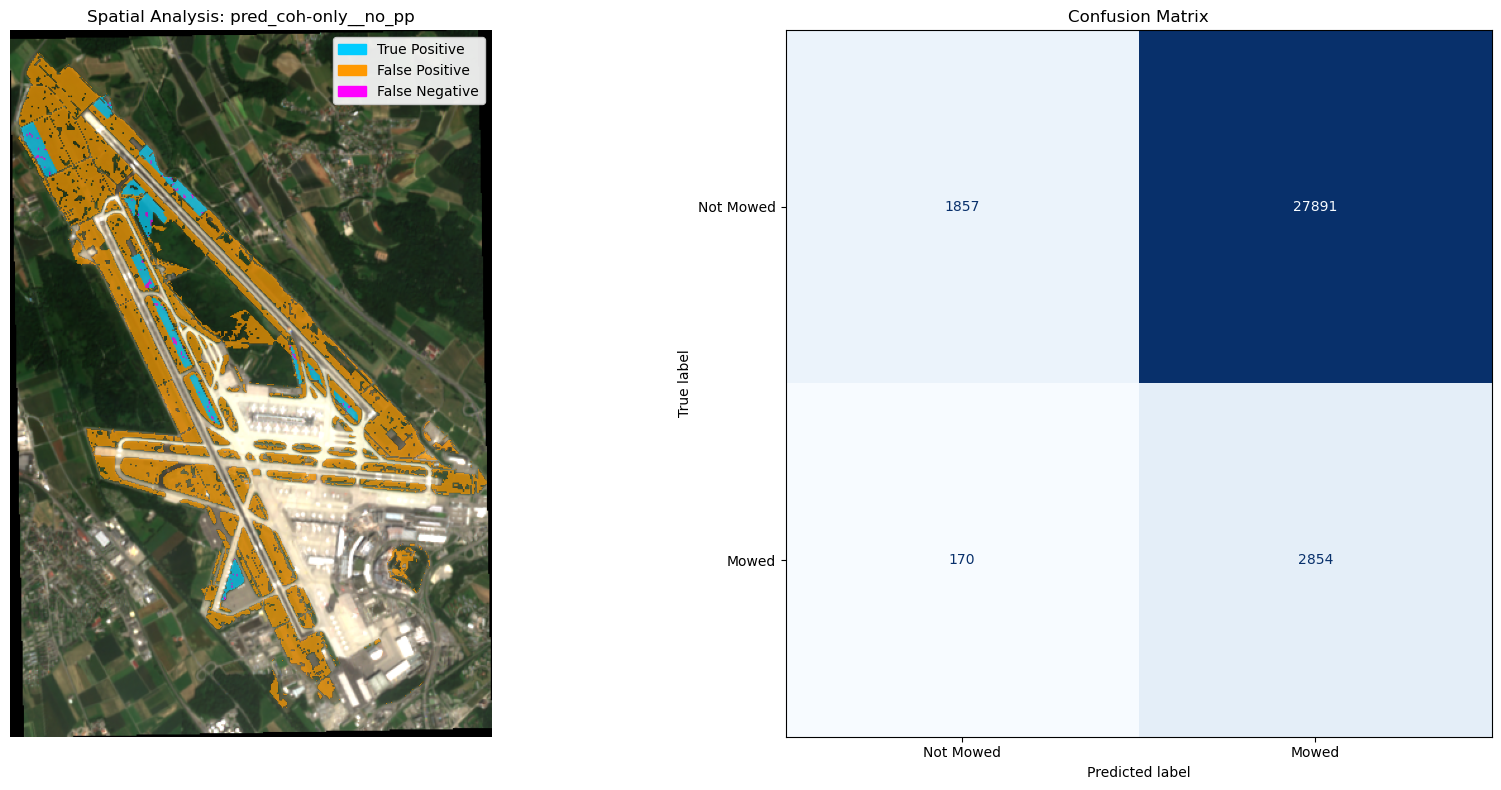


Coh-only | Morph+SLIC  (threshold=0.3590)
Predicting on 32,772 valid pixels (threshold=0.359)...
Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\pred_coh-only__morphplusslic.tif
REPORT: pred_coh-only__morphplusslic_pp
              precision    recall  f1-score   support

   No Mowing       0.96      0.26      0.41     29748
      Mowing       0.11      0.90      0.20      3024

    accuracy                           0.32     32772
   macro avg       0.54      0.58      0.30     32772
weighted avg       0.88      0.32      0.39     32772

Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\eval_map_pred_coh-only__morphplusslic_pp.png


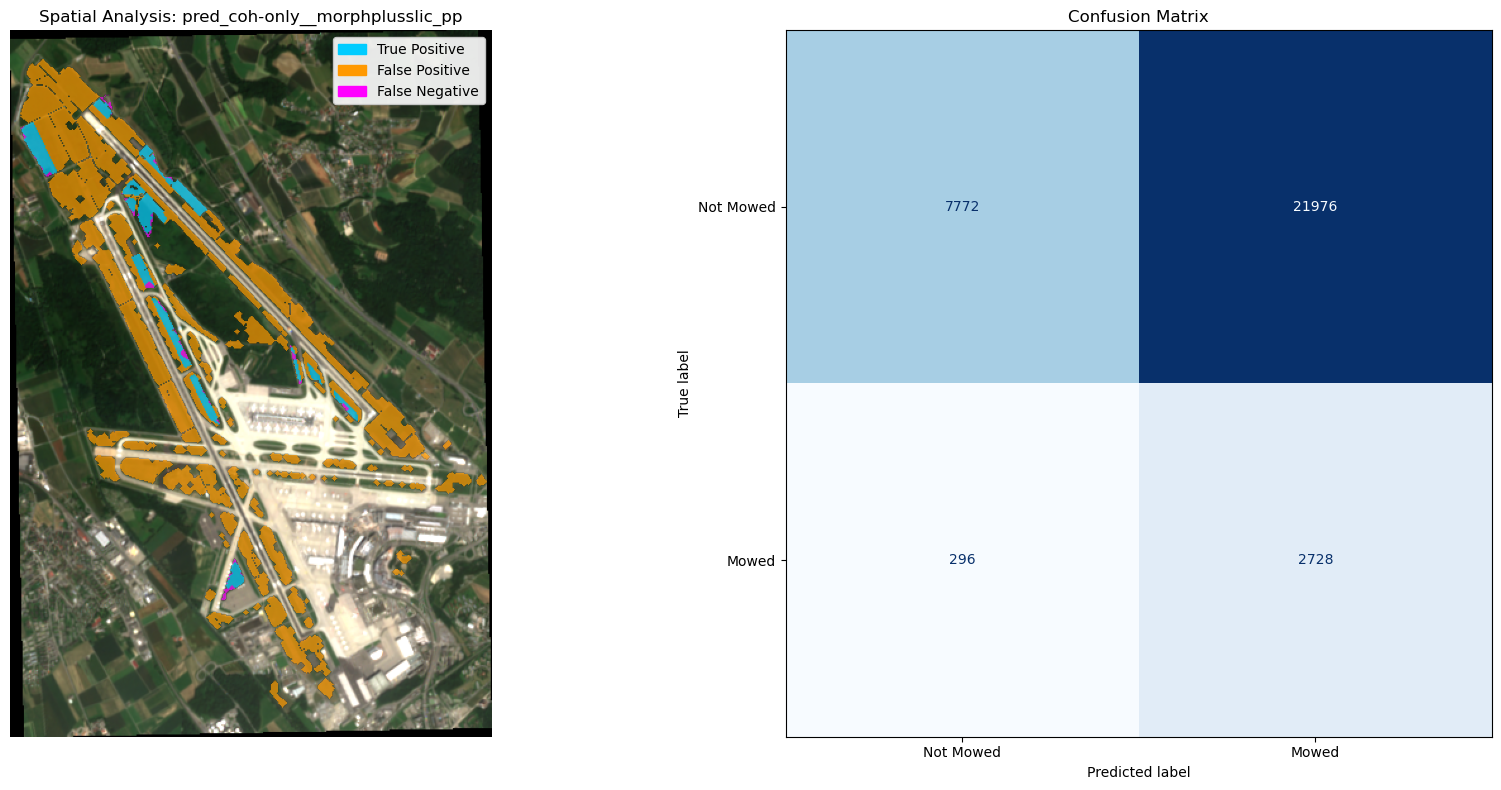

{'accuracy': 0.3203954595386305,
 'precision_mowing': 0.11042746113989638,
 'recall_mowing': 0.9021164021164021,
 'f1_mowing': 0.19676860934795154,
 'f1_macro': 0.3039057770666138}

In [144]:
# E: Coh-only, no postprocessing
run_cell('Coh-only | No PP',
         model_coh, feature_df_coh, valid_mask_coh, feat_coh,
         threshold=thresh_coh, postprocess=False)

# F: Coh-only, Morphological+SLIC
run_cell('Coh-only | Morph+SLIC',
         model_coh, feature_df_coh, valid_mask_coh, feat_coh,
         threshold=thresh_coh, postprocess=True, pp_fn=apply_postprocessing)

---
## 7. Results Table

In [145]:
def fmt(key):
    m = table_results.get(key)
    if m is None:
        return 'N/A'
    return f'F1={m["f1_mowing"]:.3f}  (P={m["precision_mowing"]:.3f}, R={m["recall_mowing"]:.3f})'

col_w = 42
print(f"=== 3x2 Operational Evaluation — match_id={CHOSEN_MATCH_ID}, "
      f"date={event['event_date'].date()} ===")
print(f'{"":22} {"No Postprocessing":{col_w}} {"Morphological+SLIC":{col_w}}')
print('-' * (22 + col_w * 2 + 2))
for row_label, no_pp_key, pp_key in [
    ('S2-only',  'S2-only | No PP',  'S2-only | Morph+SLIC'),
    ('S2+Coh',   'S2+Coh | No PP',   'S2+Coh | Morph+SLIC'),
    ('Coh-only', 'Coh-only | No PP', 'Coh-only | Morph+SLIC'),
]:
    print(f'{row_label:22} {fmt(no_pp_key):{col_w}} {fmt(pp_key):{col_w}}')
print()
print('Reference — PA2 baseline (S2-only, no PP): F1 = 0.27–0.41  (on 2020-08-12)')
print('Reference — PA2 best     (S2-only, Morph+SLIC): F1 = 0.508  (on 2020-08-12)')

=== 3x2 Operational Evaluation — match_id=12, date=2019-06-23 ===
                       No Postprocessing                          Morphological+SLIC                        
------------------------------------------------------------------------------------------------------------
S2-only                F1=0.301  (P=0.184, R=0.827)               F1=0.457  (P=0.323, R=0.783)              
S2+Coh                 F1=0.235  (P=0.135, R=0.910)               F1=0.368  (P=0.234, R=0.857)              
Coh-only               F1=0.169  (P=0.093, R=0.944)               F1=0.197  (P=0.110, R=0.902)              

Reference — PA2 baseline (S2-only, no PP): F1 = 0.27–0.41  (on 2020-08-12)
Reference — PA2 best     (S2-only, Morph+SLIC): F1 = 0.508  (on 2020-08-12)


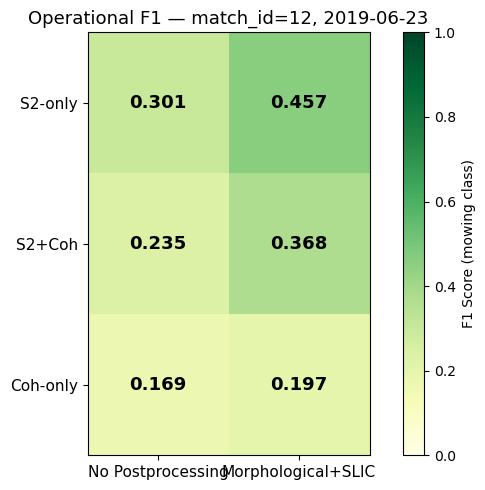

Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\results_3x2_12.png


In [146]:
row_labels = ['S2-only', 'S2+Coh', 'Coh-only']
col_labels = ['No Postprocessing', 'Morphological+SLIC']
keys = [
    ('S2-only | No PP',  'S2-only | Morph+SLIC'),
    ('S2+Coh | No PP',   'S2+Coh | Morph+SLIC'),
    ('Coh-only | No PP', 'Coh-only | Morph+SLIC'),
]

matrix = np.array([
    [table_results.get(nk, {}).get('f1_mowing', np.nan),
     table_results.get(pk, {}).get('f1_mowing', np.nan)]
    for nk, pk in keys
])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(matrix, cmap='YlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='F1 Score (mowing class)')
ax.set_xticks([0, 1]); ax.set_xticklabels(col_labels, fontsize=11)
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(row_labels, fontsize=11)
for i in range(3):
    for j in range(2):
        val = matrix[i, j]
        ax.text(j, i, f'{val:.3f}' if not np.isnan(val) else 'N/A',
                ha='center', va='center', fontsize=13, fontweight='bold',
                color='white' if val > 0.6 else 'black')
ax.set_title(f"Operational F1 — match_id={CHOSEN_MATCH_ID}, "
             f"{event['event_date'].date()}", fontsize=13)
plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, f'results_3x2_{CHOSEN_MATCH_ID}.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_png}')

---
## 8. Save Results to CSV

Append this run to `eval_table.csv` so results accumulate across scenes.


In [ ]:
import datetime

records = []
for label, metrics in table_results.items():
    if metrics is None:
        continue
    parts = label.split(' | ', 1)
    model_name = parts[0]
    pp_label   = parts[1] if len(parts) > 1 else 'unknown'
    records.append({
        'match_id':        CHOSEN_MATCH_ID,
        'event_date':      str(event['event_date'].date()),
        'model':           model_name,
        'postprocessing':  pp_label,
        'precision':       round(metrics['precision_mowing'], 4),
        'recall':          round(metrics['recall_mowing'], 4),
        'f1':              round(metrics['f1_mowing'], 4),
        'f1_macro':        round(metrics['f1_macro'], 4),
        'run_ts':          datetime.datetime.now().isoformat(timespec='seconds'),
    })

if records:
    new_df = pd.DataFrame(records)
    csv_path = RESULTS_DIR / 'eval_table.csv'
    if csv_path.exists():
        existing = pd.read_csv(csv_path)
        existing = existing[existing['match_id'] != CHOSEN_MATCH_ID]
        new_df = pd.concat([existing, new_df], ignore_index=True)
    new_df.to_csv(csv_path, index=False)
    print(f'Results saved to: {csv_path}')
    print(new_df[['match_id', 'event_date', 'model', 'postprocessing',
                   'precision', 'recall', 'f1']].to_string(index=False))
else:
    print('No results to save (all cells were skipped)')

---
## 9. Postprocessing Parameter Grid Search

Systematically evaluates combinations of postprocessing parameters.
Runs on the **S2-only raw prediction** (model fixed, only postprocessing varies).
Change `GRID_MODEL` below to switch to a different model.

**Edit only the `PP_GRID` dict in the next cell** — that is the single place to add/remove values.

In [149]:
import importlib, src.postprocessing
importlib.reload(src.postprocessing)                      # pick up slic_threshold from postprocessing.py
from src.postprocessing import postprocess_prediction
from sklearn.metrics import f1_score, precision_score, recall_score
import itertools

# ── Choose which model / valid mask to use for the grid search ────────────
GRID_MODEL      = model_s2        # change to model_s2 / model_coh if desired
GRID_FEATURES   = feat_s2         # matching feature list
GRID_FEAT_DF    = feature_df_s2   # matching feature DataFrame
GRID_VALID_MASK = valid_mask      # matching valid pixel mask
GRID_THRESHOLD  = thresh_s2       # calibrated threshold from nb08 PR curve

# ══════════════════════════════════════════════════════════════════════════
# POSTPROCESSING PARAMETER GRID  ←  edit values here only
# ══════════════════════════════════════════════════════════════════════════
PP_GRID = {
    # Which postprocessing pipeline(s) to test
    'method':           ['morphological', 'morphological+slic'],

    # Morphological: disk radius for binary opening/closing
    # 0 = no erosion/dilation (only area filter); higher = more aggressive smoothing
    'disk_radius':      [0, 1, 2, 3],

    # Morphological: connected components smaller than this are removed
    'min_area_pixels':  [4, 16, 32],

    # SLIC: number of superpixels (only used when method contains 'slic')
    # More segments → smaller, spatially tighter superpixels
    'n_segments':       [400, 800, 1600],

    # SLIC: spatial vs. spectral weight (only used with slic)
    # Low (0.05) = spectral-only clustering; high (1.0+) = spatially compact segments
    'slic_compactness': [0.3, 1.0, 3.0],

    # SLIC: fraction of valid pixels in a segment that must be mowed to vote "mowed"
    # Lower threshold = more sensitive; ~0.25-0.35 suits a ~30% mowed prediction rate
    'slic_threshold':   [0.2, 0.3, 0.5],
}
# ══════════════════════════════════════════════════════════════════════════

# ── Compute raw prediction with calibrated threshold (no postprocessing) ──
# Using predict_proba + GRID_THRESHOLD instead of model.predict (0.5 default)
pred_flat_raw = np.full(H * W, -1, dtype=np.int8)
if GRID_VALID_MASK.sum() > 0:
    proba = GRID_MODEL.predict_proba(
        GRID_FEAT_DF[GRID_FEATURES][GRID_VALID_MASK]
    )[:, 1]
    pred_flat_raw[GRID_VALID_MASK] = (proba >= GRID_THRESHOLD).astype(np.int8)
pred_map_raw = pred_flat_raw.reshape(H, W)
print(f'Raw prediction (threshold={GRID_THRESHOLD:.4f}): '
      f'{(pred_map_raw == 1).sum():,} mowed / '
      f'{GRID_VALID_MASK.sum():,} valid pixels  '
      f'({100*(pred_map_raw==1).sum()/max(GRID_VALID_MASK.sum(),1):.1f}% mowed)')

# ── Load and union GT masks ───────────────────────────────────────────────
gt_union = np.zeros((H, W), dtype=np.uint8)
for mask_name in GT_MASK_NAMES:
    gt_path = Path(MASKS_DIR) / mask_name
    if not gt_path.exists():
        print(f'  GT mask not found: {mask_name}')
        continue
    with rasterio.open(gt_path) as src_gt:
        arr = src_gt.read(1)
        if arr.shape == (H, W):
            gt_union = np.maximum(gt_union, arr.astype(np.uint8))
        else:
            from rasterio.warp import reproject, Resampling as RS
            dst = np.zeros((H, W), dtype=np.float32)
            reproject(arr.astype(np.float32), dst,
                      src_transform=src_gt.transform, src_crs=src_gt.crs,
                      dst_transform=meta['transform'], dst_crs=meta['crs'],
                      resampling=RS.nearest)
            gt_union = np.maximum(gt_union, (dst > 0.5).astype(np.uint8))

gt_valid = gt_union.flatten()[GRID_VALID_MASK]
print(f'GT mowed pixels (in valid area): {gt_valid.sum():,} / {GRID_VALID_MASK.sum():,}')

# ── Count total unique combinations ──────────────────────────────────────
n_morph = len(PP_GRID['disk_radius']) * len(PP_GRID['min_area_pixels'])
n_slic  = (len(PP_GRID['disk_radius']) * len(PP_GRID['min_area_pixels']) *
           len(PP_GRID['n_segments'])   * len(PP_GRID['slic_compactness']) *
           len(PP_GRID['slic_threshold']))
total = (n_morph if 'morphological' in PP_GRID['method'] else 0) + \
        (n_slic  if 'morphological+slic' in PP_GRID['method'] else 0)
print(f'\nGrid: {total} unique combinations  '
      f'({n_morph} morphological-only + {n_slic} morphological+slic)')

Raw prediction (threshold=0.2855): 13,614 mowed / 32,772 valid pixels  (41.5% mowed)
GT mowed pixels (in valid area): 3,024 / 32,772

Grid: 336 unique combinations  (12 morphological-only + 324 morphological+slic)


In [150]:
grid_records = []
seen_keys    = set()
pred_valid_raw = pred_map_raw.flatten()[GRID_VALID_MASK]

all_methods = PP_GRID['method']
all_dr  = PP_GRID['disk_radius']
all_ma  = PP_GRID['min_area_pixels']
all_ns  = PP_GRID['n_segments']
all_sc  = PP_GRID['slic_compactness']
all_st  = PP_GRID['slic_threshold']

for method in all_methods:
    has_slic = 'slic' in method
    slic_combos = list(itertools.product(all_ns, all_sc, all_st)) if has_slic else [(None, None, None)]

    for dr, ma in itertools.product(all_dr, all_ma):
        for ns, sc, st in slic_combos:
            # Deduplicate: morphological params that differ only in unused slic params
            key = (method, dr, ma, ns, sc, st) if has_slic else (method, dr, ma)
            if key in seen_keys:
                continue
            seen_keys.add(key)

            pp_map = postprocess_prediction(
                pred_map_raw,
                method=method,
                scene_image=scene_rgb,
                disk_radius=dr,
                min_area_pixels=ma,
                n_segments=ns    if ns is not None else 300,
                slic_compactness=sc if sc is not None else 0.05,
                slic_threshold=st   if st is not None else 0.5,
            )

            pp_valid = pp_map.flatten()[GRID_VALID_MASK]
            f1  = f1_score(gt_valid, pp_valid, pos_label=1, zero_division=0)
            pre = precision_score(gt_valid, pp_valid, pos_label=1, zero_division=0)
            rec = recall_score(gt_valid, pp_valid, pos_label=1, zero_division=0)
            n_mowed = int((pp_valid == 1).sum())

            row = {
                'method': method, 'disk_radius': dr, 'min_area_px': ma,
                'n_segments': ns, 'compactness': sc, 'threshold': st,
                'f1': round(f1, 4), 'precision': round(pre, 4),
                'recall': round(rec, 4), 'n_mowed_pred': n_mowed,
            }
            grid_records.append(row)

grid_df = pd.DataFrame(grid_records).sort_values('f1', ascending=False).reset_index(drop=True)

print(f'Completed {len(grid_df)} combinations.\n')

# ── Top 15 results ────────────────────────────────────────────────────────
display_cols = ['method', 'disk_radius', 'min_area_px', 'n_segments',
                'compactness', 'threshold', 'f1', 'precision', 'recall', 'n_mowed_pred']
print('Top 15 postprocessing configurations by F1:')
print(grid_df[display_cols].head(15).to_string(index=True))
print()

# ── Best morphological-only (fast, reproducible) ─────────────────────────
morph_only = grid_df[grid_df['method'] == 'morphological']
if not morph_only.empty:
    best_morph = morph_only.iloc[0]
    print(f'Best morphological-only:  F1={best_morph["f1"]:.4f}  '
          f'disk_radius={best_morph["disk_radius"]}  '
          f'min_area_px={best_morph["min_area_px"]}')

# ── Best morphological+slic ───────────────────────────────────────────────
morph_slic = grid_df[grid_df['method'] == 'morphological+slic']
if not morph_slic.empty:
    best_slic = morph_slic.iloc[0]
    print(f'Best morphological+slic:  F1={best_slic["f1"]:.4f}  '
          f'disk_radius={best_slic["disk_radius"]}  '
          f'min_area_px={best_slic["min_area_px"]}  '
          f'n_segments={best_slic["n_segments"]}  '
          f'compactness={best_slic["compactness"]}  '
          f'threshold={best_slic["threshold"]}')

# ── Raw (no postprocessing) baseline for comparison ──────────────────────
f1_raw = f1_score(gt_valid, pred_valid_raw, pos_label=1, zero_division=0)
pre_raw = precision_score(gt_valid, pred_valid_raw, pos_label=1, zero_division=0)
rec_raw = recall_score(gt_valid, pred_valid_raw, pos_label=1, zero_division=0)
print(f'\nNo postprocessing baseline: F1={f1_raw:.4f}  '
      f'P={pre_raw:.4f}  R={rec_raw:.4f}  '
      f'n_mowed={int((pred_valid_raw==1).sum())}')

Completed 336 combinations.

Top 15 postprocessing configurations by F1:
                method  disk_radius  min_area_px  n_segments  compactness  threshold      f1  precision  recall  n_mowed_pred
0        morphological            3           32         NaN          NaN        NaN  0.5261     0.4238  0.6935          4948
1        morphological            3           16         NaN          NaN        NaN  0.5242     0.4213  0.6935          4977
2        morphological            3            4         NaN          NaN        NaN  0.5242     0.4213  0.6935          4977
3   morphological+slic            3            4      1600.0          3.0        0.5  0.5172     0.4463  0.6147          4165
4   morphological+slic            3           32      1600.0          3.0        0.5  0.5172     0.4463  0.6147          4165
5   morphological+slic            3           16      1600.0          3.0        0.5  0.5172     0.4463  0.6147          4165
6        morphological            2          

---
## Summary

This notebook produces a 3x2 operational F1 table comparing:
- **S2-only** (20 optical features)
- **S2+Coh** (24 features: S2 + 4 coherence)
- **Coh-only** (4 coherence features)

... with and without Morphological+SLIC postprocessing, on the held-out 2020-08-12 scene.

**Coherence features (4):**
- `coh_vv`, `coh_vh` — VV/VH coherence for the after period (20 m, upsampled to 10 m for inference)
- `coh_vv_jump`, `coh_vh_jump` — coherence change = coh_after - coh_before

**Outputs in `data/operational_results/`:**
- `pred_*.tif` — prediction rasters for each configuration
- `eval_map_*.png` — spatial TP/FP/FN maps + confusion matrices
- `results_3x2_table.png` — heatmap summary